### Tumor and MS


* **Criterion:** **Selects the sequence with the highest read count (Best Quality).**
* **Description:** For each patient and clonotype group, this file selects only the single representative sequence that has the maximum `total_counts` (gene expression/read counts).
* **Use Case:** Suitable when prioritizing sequencing quality or maximum expression levels to define the dominant sequence of a clone.

**Quick Summary**
* `_totalcount`: Selects **1 sequence with the highest expression** (total counts) per clone.


tumor_n_clones: 105
sample type sample_type
BM    93
PB    12
dtype: int64
Diagnosis Diagnosis_MS
MGUS         11
MGUS+MGIP     3
MM           11
MM+MGIP       1
SMM          70
SMM+MGIP      9
dtype: int64
--- MS_conc Distribution ---
Mean  : 17.1682
Median: 15.6420
Min  : 0.5410
Max: 60.8590
15%   : 4.2430
25%   : 6.4200
75%   : 22.9020


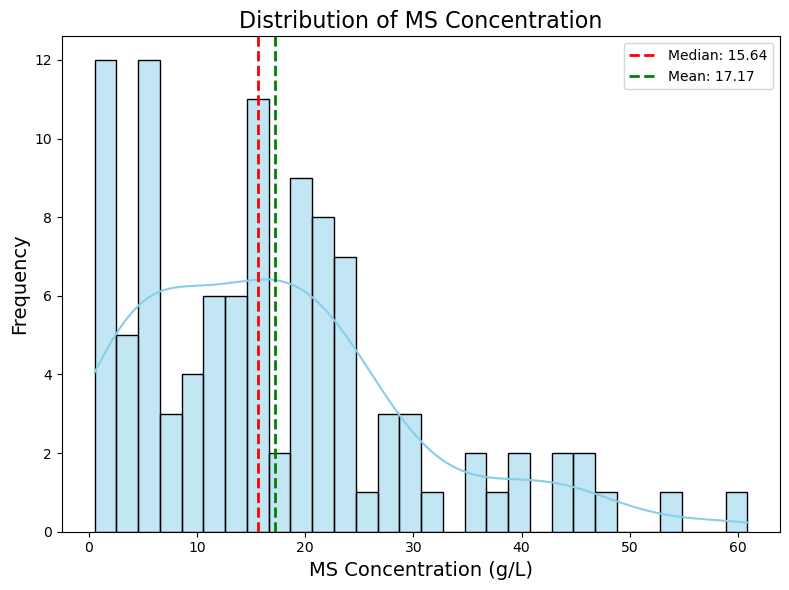

--- Plotting Concentration vs Tumor Cells ---


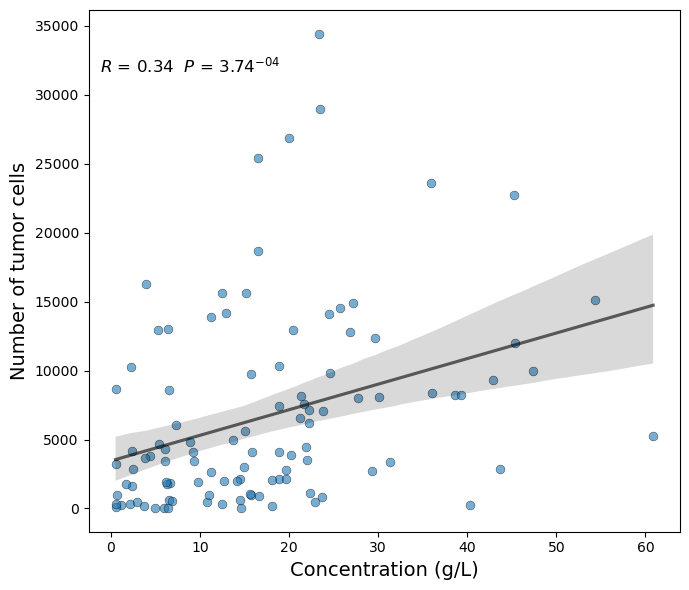


--- Difference (mz_diff) Distribution ---
  [Total     ] Min:  0.0112 | 15%:  0.2638 | 50%:  6.7565 | 75%: 13.4210 | Max: 143.9694
  [IGHA      ] Min:  0.0176 | 15%:  0.4657 | 50%:  7.2960 | 75%:  9.4820 | Max: 143.9694
  [IGHG      ] Min:  0.0112 | 15%:  0.2201 | 50%:  1.5853 | 75%: 13.6169 | Max: 65.1258




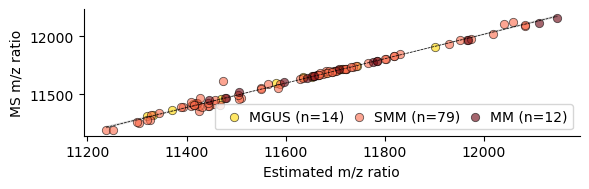

--- Plotting mz_diff Distributions ---


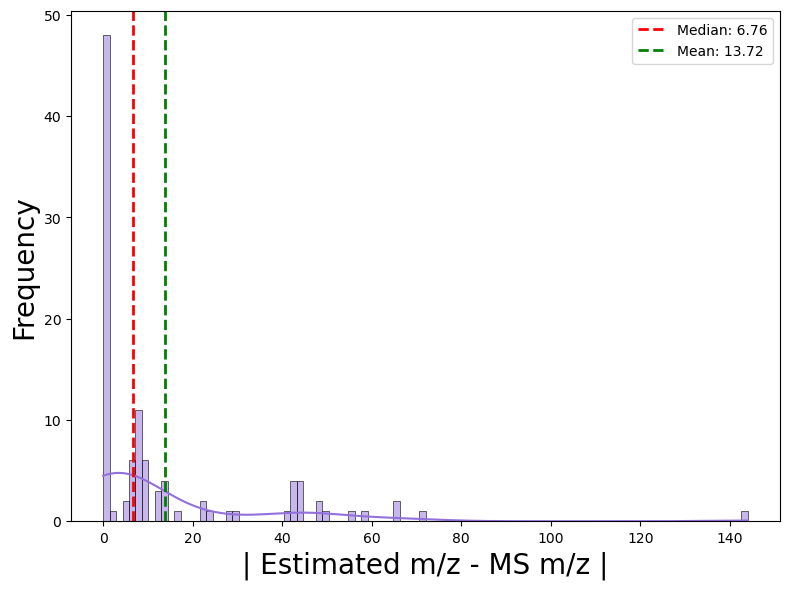

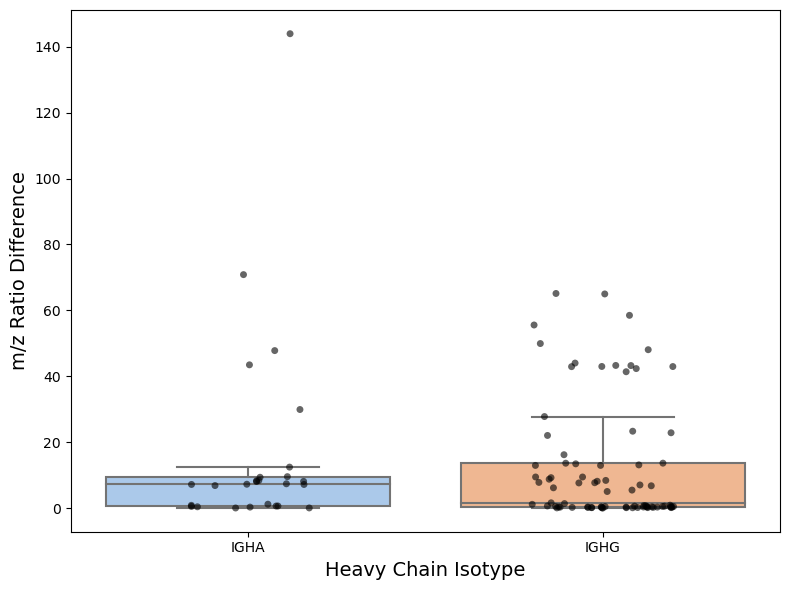

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from itertools import combinations

def process_heavy_c_gene(row):
    genes = row.split(",") if isinstance(row, str) else []
    processed_genes = [gene[:-1] for gene in genes]

    if processed_genes:
        return max(set(processed_genes), key=processed_genes.count)
    else:
        return None

def print_diff_stats(df, label):
    diff_min = df['mz_diff'].min()
    diff_max = df['mz_diff'].max()
    diff_q15 = df['mz_diff'].quantile(0.15)
    diff_q50 = df['mz_diff'].median()
    diff_q75 = df['mz_diff'].quantile(0.75)
    
    print(f"  [{label:<10}] Min: {diff_min:>7.4f} | 15%: {diff_q15:>7.4f} | 50%: {diff_q50:>7.4f} | 75%: {diff_q75:>7.4f} | Max: {diff_max:>7.4f}")


tumor_df_final_clone = pd.read_csv('../data/tumor_df_final_subclonal_totalcount.csv', sep=",")

tumor_clo = len(tumor_df_final_clone)
filt_clo = len(tumor_df_final_clone[tumor_df_final_clone['abs_mz_diff'] < 10])

print('tumor_n_clones:', tumor_clo)
print('sample type', tumor_df_final_clone.groupby(['sample_type']).size())
print('Diagnosis', tumor_df_final_clone.groupby(['Diagnosis_MS']).size())


# -------------------------------------------------------------------------
# 0. MS concentration distribuition in PCROWD
# -------------------------------------------------------------------------
conc_mean = tumor_df_final_clone['MS_conc'].mean()
conc_median = tumor_df_final_clone['MS_conc'].median()
conc_min = tumor_df_final_clone['MS_conc'].min()
conc_max = tumor_df_final_clone['MS_conc'].max()
conc_q15 = tumor_df_final_clone['MS_conc'].quantile(0.15)
conc_q25 = tumor_df_final_clone['MS_conc'].quantile(0.25) # Q1
conc_q75 = tumor_df_final_clone['MS_conc'].quantile(0.75) # Q3

print("--- MS_conc Distribution ---")
print(f"Mean  : {conc_mean:.4f}")
print(f"Median: {conc_median:.4f}")
print(f"Min  : {conc_min:.4f}")
print(f"Max: {conc_max:.4f}")
print(f"15%   : {conc_q15:.4f}")
print(f"25%   : {conc_q25:.4f}")
print(f"75%   : {conc_q75:.4f}")

plt.figure(figsize=(8, 6))
sns.histplot(tumor_df_final_clone['MS_conc'].dropna(), bins=30, kde=True, color='skyblue')

plt.axvline(conc_median, color='red', linestyle='dashed', linewidth=2, label=f'Median: {conc_median:.2f}')
plt.axvline(conc_mean, color='green', linestyle='dashed', linewidth=2, label=f'Mean: {conc_mean:.2f}')

plt.xlabel('MS Concentration (g/L)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of MS Concentration', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 1. Tumor cell count vs Concentration plots
# -------------------------------------------------------------------------

print(f"--- Plotting Concentration vs Tumor Cells ---")

plot_df = tumor_df_final_clone.copy()

cell_n = 'clonal_aa'

plt.figure(figsize=(7, 6))
corr, pval = pearsonr(plot_df['MS_conc'], plot_df[cell_n])

sns.scatterplot(
    x='MS_conc', y=cell_n,
    data=plot_df,
    palette='deep',
    s=40,
    linewidth=0.4,
    edgecolor='black',
    alpha=0.6,
)

sns.regplot(
    x='MS_conc', y=cell_n,
    data=plot_df,
    scatter=False,
    line_kws={'color': 'black', 'alpha' : 0.6},
)

ax = plt.gca()
base, exponent = f'{pval:.2e}'.split('e')
formatted_pval = f'{base}$^{{{exponent}}}$'  

plt.text(
    0.02, 0.88, 
    f'$\\it{{R}}$ = {corr:.2f}  $\\it{{P}}$ = {formatted_pval}', 
    transform=ax.transAxes, 
    fontsize=12, 
    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
)

plt.xlabel('Concentration (g/L)', fontsize=14)
plt.ylabel('Number of tumor cells', fontsize=14)
plt.tight_layout()

plt.savefig(f'../00.Figures/tumor_MSconc_correlation_PCROWD.pdf', format='pdf', bbox_inches='tight')
plt.show()

x = 'est_mz_ratio'
y = 'MS_mz_ratio'

tumor_df_final_clone['mz_diff'] = abs(tumor_df_final_clone[y] - tumor_df_final_clone[x])
tumor_df_final_clone['heavy_c_gene'] = tumor_df_final_clone['heavy_c_gene_all_contig'].apply(process_heavy_c_gene)

print(f"\n--- Difference (mz_diff) Distribution ---")
print_diff_stats(tumor_df_final_clone, "Total")

for iso in sorted(tumor_df_final_clone['heavy_c_gene'].dropna().unique()):
    iso_df = tumor_df_final_clone[tumor_df_final_clone['heavy_c_gene'] == iso]
    print_diff_stats(iso_df, iso)
print("\n")

# -------------------------------------------------------------------------
# 2. m/z ratio lmplot
# -------------------------------------------------------------------------
corr, pval = pearsonr(tumor_df_final_clone[x], tumor_df_final_clone[y])
font_size = 10

tumor_df_final_clone['Diag_clean'] = tumor_df_final_clone['Diagnosis_MS'].str.replace('+MGIP', '', regex=False).str.strip()

diag_counts = tumor_df_final_clone['Diag_clean'].value_counts()

tumor_df_final_clone['Diag_label'] = tumor_df_final_clone['Diag_clean'].apply(lambda d: f"{d} (n={diag_counts[d]})")

custom_palette = {}
for label in tumor_df_final_clone['Diag_label'].unique():
    if 'MGUS' in label:
        custom_palette[label] = '#ffd700'
    elif 'SMM' in label:
        custom_palette[label] = '#fb6a4a' 
    elif 'MM' in label:
        custom_palette[label] = '#67000d'
    else:
        custom_palette[label] = '#999999'  
    
g = sns.lmplot(
    x=x, y=y, data=tumor_df_final_clone, 
    height=2, aspect=3,
    hue='Diag_label', palette=custom_palette,
    fit_reg=False, 
    legend=False,
    scatter_kws={'alpha': 0.6, 'edgecolor': 'black', 'linewidth': 0.6}
)

sns.regplot(
    x=x, y=y, data=tumor_df_final_clone,
    scatter=False, 
    ax=g.ax, 
    line_kws={'color': 'black', 'linestyle': '--', 'alpha': 1, 'linewidth' : 0.5}
)

g.set_axis_labels("Estimated m/z ratio", "MS m/z ratio", fontsize=font_size)
g.ax.tick_params(axis='both', which='major', labelsize=font_size)

plt.legend(bbox_to_anchor=(1, -0.005), loc='lower right', 
           columnspacing=0.1, handletextpad=0.05,
           ncol=3, fontsize=font_size, title='')

# g.ax.text(0.05, 0.95, 
#          f'Correlation coefficient: {corr:.2f}\np-value: {pval:.2e}', 
#          transform=g.ax.transAxes, fontsize=font_size, 
#          verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.savefig(f'../00.Figures/est_MS_mz_ratio_comparison_PCROWD.pdf', format='pdf', bbox_inches='tight')
plt.show()               


# -------------------------------------------------------------------------
# 3. mz_diff distribution & Isotype comparison plots
# -------------------------------------------------------------------------
print("--- Plotting mz_diff Distributions ---")

plt.figure(figsize=(8, 6))
diff_median = tumor_df_final_clone['mz_diff'].median()
diff_mean = tumor_df_final_clone['mz_diff'].mean()

sns.histplot(tumor_df_final_clone['mz_diff'].dropna(), bins=100, kde=True, color='mediumpurple')

plt.axvline(diff_median, color='red', linestyle='dashed', linewidth=2, label=f'Median: {diff_median:.2f}')
plt.axvline(diff_mean, color='green', linestyle='dashed', linewidth=2, label=f'Mean: {diff_mean:.2f}')

plt.xlabel('| Estimated m/z - MS m/z |', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.legend()
plt.tight_layout()
plt.savefig('../00.Figures/mz_diff_distribution_overall_PCROWD.pdf', format='pdf', bbox_inches='tight')
plt.show()

valid_iso_df = tumor_df_final_clone.dropna(subset=['heavy_c_gene', 'mz_diff']).copy()
valid_iso_df = valid_iso_df.sort_values('heavy_c_gene')

plt.figure(figsize=(8, 6))
sns.boxplot(
    x='heavy_c_gene', y='mz_diff', 
    data=valid_iso_df, 
    palette='pastel', 
    showfliers=False 
)
sns.stripplot(
    x='heavy_c_gene', y='mz_diff', 
    data=valid_iso_df, 
    color='black', alpha=0.6, jitter=0.2, size=5
)

plt.xlabel('Heavy Chain Isotype', fontsize=14)
plt.ylabel('m/z Ratio Difference', fontsize=14)
plt.tight_layout()
plt.savefig('../00.Figures/mz_diff_distribution_by_isotype_PCROWD.pdf', format='pdf', bbox_inches='tight')
plt.show()